In [3]:
# %%
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "visitor_features_engineered.parquet"
df = pd.read_parquet(DATA_PATH)

# Only visitors who started a test
df_started = df[df["test_engagement_state"] != "No Test"].copy()

df_started.shape

(502735, 15)

In [9]:
# %%
df_started["abandoned"] = (
    df_started["test_engagement_state"] == "Test Started Only"
)

df_started["abandoned"].value_counts(normalize=True)

abandoned
False    0.845744
True     0.154256
Name: proportion, dtype: float64

In [10]:
pd.crosstab(
    df_started["test_engagement_state"],
    df_started["abandoned"]
)

abandoned,False,True
test_engagement_state,,
Test Completed,425185,0
Test Started Only,0,77550


In [11]:
# %%
domain_abandonment = (
    df_started
    .groupby("first_test_domain")
    .agg(
        started_visitors=("visitor_key", "count"),
        abandoned_visitors=("abandoned", "sum")
    )
    .assign(
        completed_visitors=lambda d: d["started_visitors"] - d["abandoned_visitors"],
        abandonment_rate=lambda d: d["abandoned_visitors"] / d["started_visitors"]
    )
    .sort_values("abandonment_rate", ascending=False)
)

domain_abandonment

,started_visitors,abandoned_visitors,completed_visitors,abandonment_rate
first_test_domain,,,,
"Life, Work & Physical Health",21660,4586,17074,0.211727
Anxiety & Stress,30685,6210,24475,0.202379
Sexual & Gender Health,62306,11386,50920,0.182743
Trauma & Dissociation,105351,18787,86564,0.178328
Addiction & Compulsive Behavior,56593,9213,47380,0.162794
Neurodevelopmental & Cognitive,10554,1497,9057,0.141842
Mood & Depression,109218,13898,95320,0.127250
Personality Disorders & Traits,106368,11973,94395,0.112562


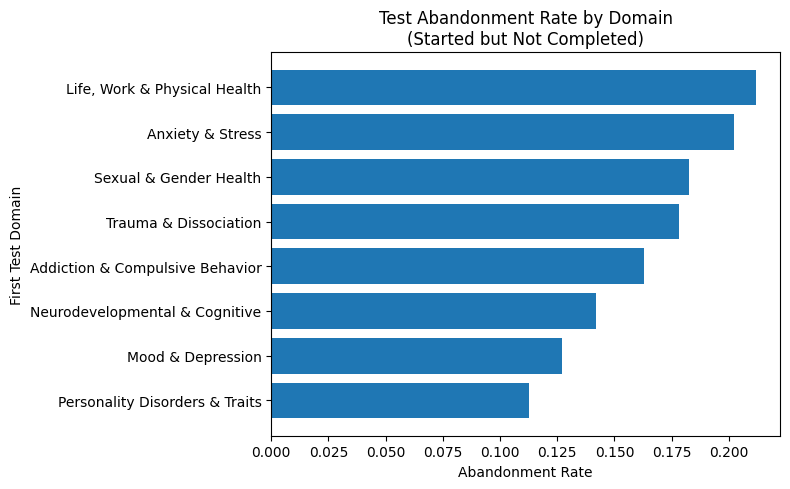

In [12]:
# %%
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(
    domain_abandonment.index,
    domain_abandonment["abandonment_rate"]
)
plt.xlabel("Abandonment Rate")
plt.ylabel("First Test Domain")
plt.title("Test Abandonment Rate by Domain\n(Started but Not Completed)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()